In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Loading data
data_1 = pd.read_csv("../data/wildfire_14_18.csv", sep = ",")
data_2 = pd.read_csv("../data/wildfire_19_23.csv", sep = ",")

print("Data loaded successfully")

Data loaded successfully


In [2]:
# Load Canada data
canada = gpd.read_file("../data/lpr_000b21a_e.zip")
print("Zip loaded successfully")

# Reproject to epsg:4326
canada = canada.to_crs(epsg = 4326)

Zip loaded successfully


In [4]:
# Generate points
geometry = gpd.points_from_xy(
    data_1["longitude"],
    data_1["latitude"]
)

# Make GeoDataFrame
data_1_gpd = gpd.GeoDataFrame(
    data_1,
    geometry=geometry,
    crs="EPSG:4326"
)

data_1_gpd.crs == canada.crs

True

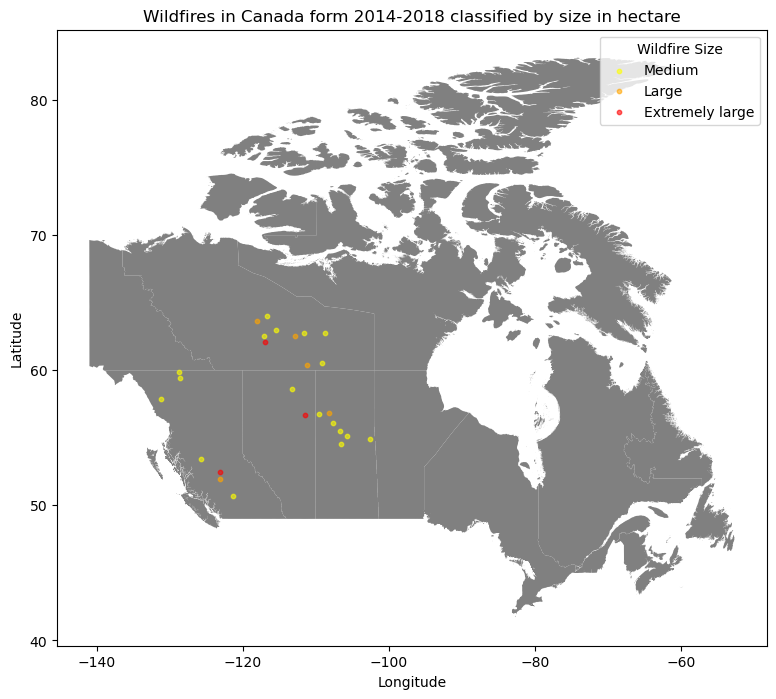

In [13]:
# Map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame directly onto our specific Axes
canada.plot(ax=ax, color="grey")

colors = {"Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# Plot each class seperatly
for category, color in colors.items():

    subset = data_1_gpd[
        data_1_gpd["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# Legende
ax.legend(title="Wildfire Size")

# Apply geographic context to the axes
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada form 2014-2018 classified by size in hectare")

plt.show()

In [8]:
# Generate points
geometry = gpd.points_from_xy(
    data_2["longitude"],
    data_2["latitude"]
)

# Make GeoDataFrame
data_2_gpd = gpd.GeoDataFrame(
    data_2,
    geometry=geometry,
    crs="EPSG:4326"
)

data_2_gpd.crs == canada.crs

True

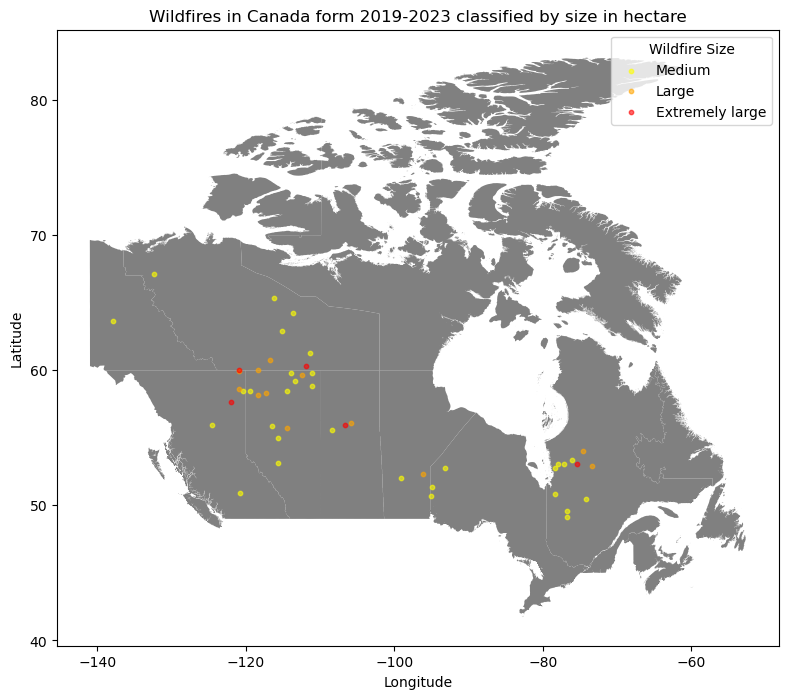

In [14]:
# Map
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the GeoDataFrame directly onto our specific Axes
canada.plot(ax=ax, color="grey")

colors = {"Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# Plot each class seperatly
for category, color in colors.items():

    subset = data_2_gpd[
        data_2_gpd["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# Legende
ax.legend(title="Wildfire Size")

# Apply geographic context to the axes
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada form 2019-2023 classified by size in hectare")

plt.show()